Project about Fitness Member Retention & Wellness Personalization Engine

The goal of this project is to analyze and predict customer churn within a fitness center environment using data-driven insights. By examining member behavior, contract patterns, and class attendance frequency, this initiative seeks to identify the key factors contributing to member attrition.

Through the implementation of machine learning classification models the project aims to build a proactive retention strategy. By identifying high-risk members early, the gym can offer personalized wellness interventions and targeted incentives, ultimately improving member lifetime value and fostering a more sustainable, long-term fitness community."

Download the data

In [67]:
#download the dataset
import pandas as pd
df = pd.read_csv('gym_churn_us.csv')

In [68]:
#chech for the shape
df.shape

(4000, 14)

In [69]:
#display the dataset
print("Dataset:")
df.head()

Dataset:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


About the dataset:

. Churn - cancellation for the current month

. Current dataset fields:

. gender.

. Near_Location - if the user lives or works in the neighborhood where the gym is located.

. Partner - if the user works in an associated company (the gym has associated companies whose employees get discounts; in those cases, the gym stores information about the clients' employers).

. Promo_friends - if the user originally signed up through a "bring a friend" offer (they used a friend's promotional code when they paid the first subscription).

. Phone - if the user provided their phone number.

.Age.

. Lifetime - the time (in months) since the user first arrived at the gym.

In [70]:
#general information :
print("Information of the dataset")
df.info()

Information of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total    

In [71]:
#check for null values:
df.isnull().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [72]:
#check negatif values
values_n = (df < 0).any()

print("Negatif values per column")
print(values_n )
print ("  ")
print ("  ")
print ("  ")
print("------"*10)
print ("  ")
print ("  ")
print("Quantity")
print((df < 0).sum())

Negatif values per column
gender                               False
Near_Location                        False
Partner                              False
Promo_friends                        False
Phone                                False
Contract_period                      False
Group_visits                         False
Age                                  False
Avg_additional_charges_total         False
Month_to_end_contract                False
Lifetime                             False
Avg_class_frequency_total            False
Avg_class_frequency_current_month    False
Churn                                False
dtype: bool
  
  
  
------------------------------------------------------------
  
  
Quantity
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Ag

The dataset has 4000 observations and 14 features with no missing or negatif values 

In [73]:
#statistic information
print("Statistics:")
df.describe().T

Statistics:


,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


In [74]:
print("\nNumerical Features Statistics:")
print(df.describe())


Numerical Features Statistics:
            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   


In [75]:
#check duplicates:
print(df.duplicated().sum())

0


In [76]:
#check the churns by group
groups_churn = df.groupby('Churn').mean()

print("Comparison between the people that churn or not):")
print(groups_churn)

Comparison between the people that churn or not):
         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                       

_Lifetime: Those who leave have been members for an average of just 1 month, compared to 4.7 months for those who stay. Conclusion: The problem occurs in the initial phase. Many new members leave almost immediately.

_Visit Frequency (Avg_class_frequency_current_month): Customers who leave visit the gym approximately once a month, while those who stay visit twice. Conclusion: Low activity is a direct predictor of churn.

_Contracts (Contract_period): Those who leave have contracts averaging 1.7 months, while those who stay have contracts averaging 5.7 months. Conclusion: Short contracts are more unstable.

_Additional revenue (Avg_additional_charges_total): Those who leave spend significantly less on additional services (115 vs. 158). Conclusion: Those who purchase extra products (classes, supplements, bar, etc.) tend to stay longer.



DATA CLEANING

In [77]:
#we will delete the column phone because it is not useful
df = df.drop('Phone', axis=1)
print("Columns", df.columns.tolist())

Columns ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Churn']


EDA

Categorical features tendencies

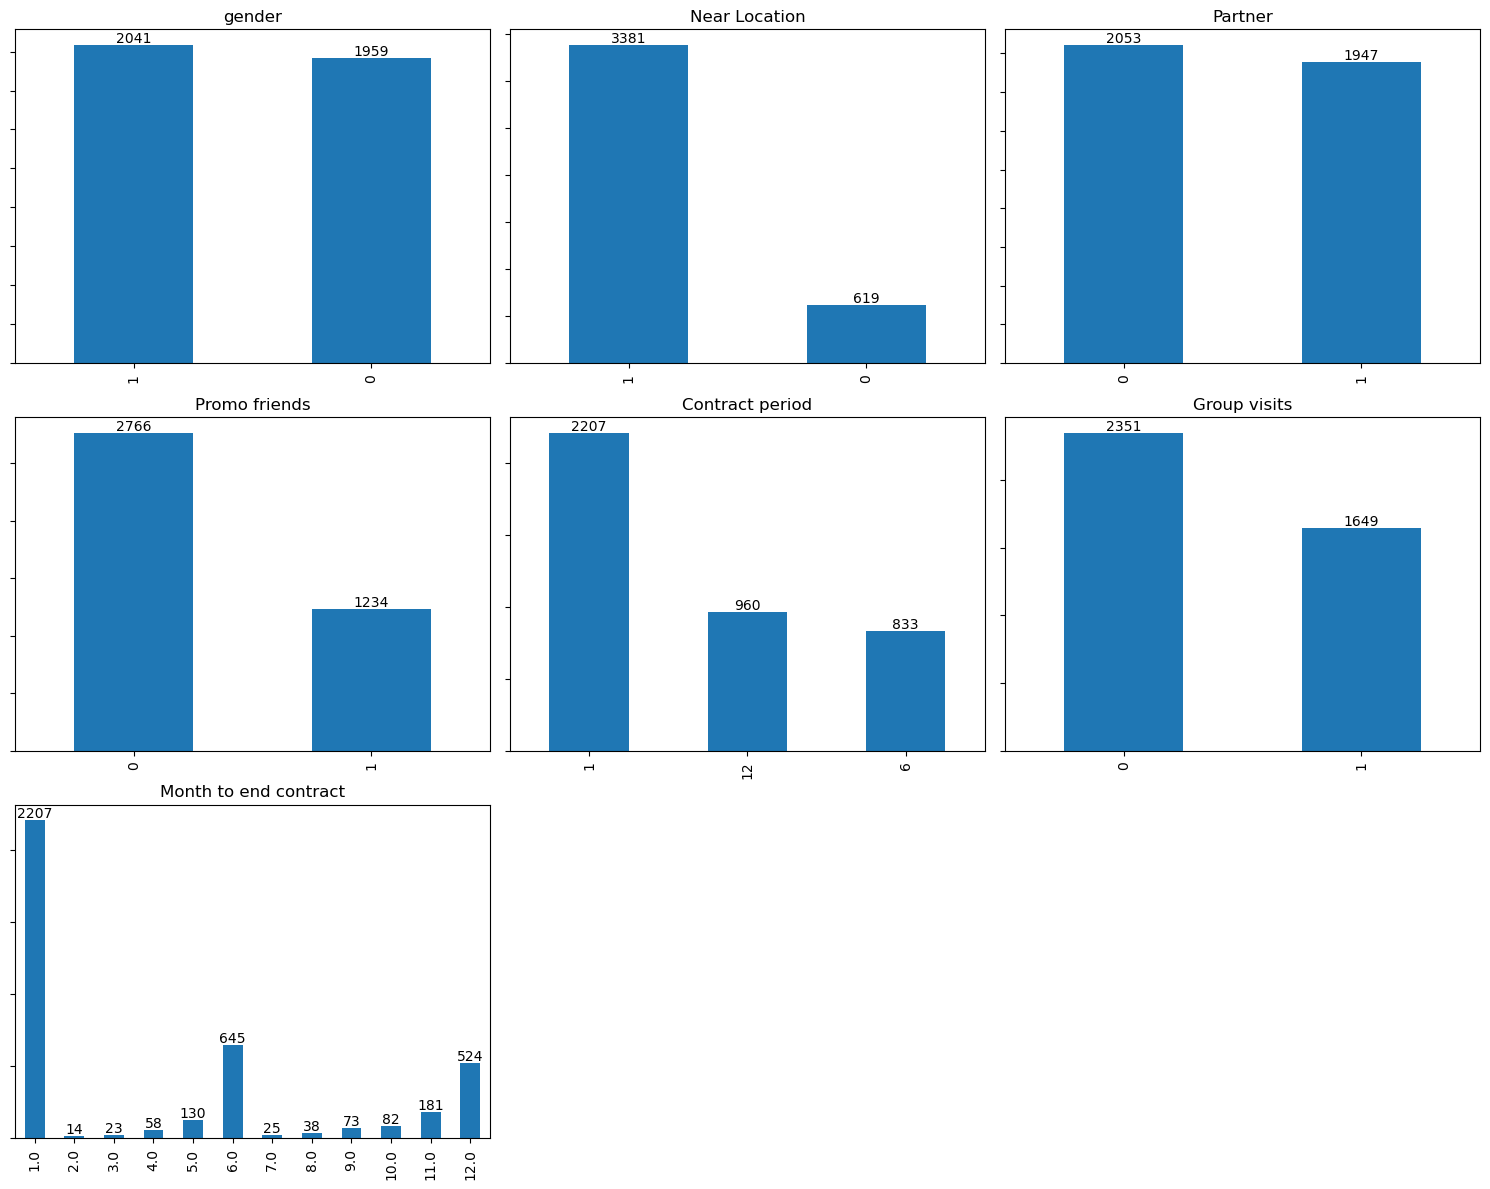

In [81]:
import matplotlib.pyplot as plt
import math

#define the categorical variables
cats = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 
        'Contract_period', 'Group_visits', 'Month_to_end_contract']

n_cols = 3 
n_rows = math.ceil(len(cats) / n_cols)

# Create the subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(cats):
    count = df[col].value_counts()
    
    if col == "Month_to_end_contract":
        count = count.sort_index()
        
    count.plot(kind="bar", ax=axes[i])
    
    for container in axes[i].containers:
        axes[i].bar_label(container)
        
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_yticklabels(()) 
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('categorical_analysis.png')

_Contract period: There is a clear trend: the vast majority of customers opt for 1-month contracts, followed by 12-month contracts. Six-month contracts are the least common. This confirms that your gym has a very large base of “transient users,” who are the primary source of churn.

_Gender: The distribution is very balanced (almost 50/50), which is good news: gender does not appear to be a significant bias factor in your analysis.

_Group visits: There is a noticeable difference in who attends group classes. This is often strongly correlated with higher retention, because the social aspect “binds” the customer to the gym.

_Near Location: A large portion of users live or work near the gym. This is an important point: if someone leaves and lives nearby, the problem is the service or the price, not logistics.

_Promo friends: Customers who are referred by friends are nearly half as likely to drop out as those who join on their own. This suggests that having someone you know at the gym dramatically increases commitment and a sense of community.

_Group Visits: Participating in group classes acts as a “protective factor” against churn. Group classes not only improve physical health, but they also establish social routines (attending at a set time, seeing the same classmates) that make it much harder for members to stop coming.



General data distribution of numerical features

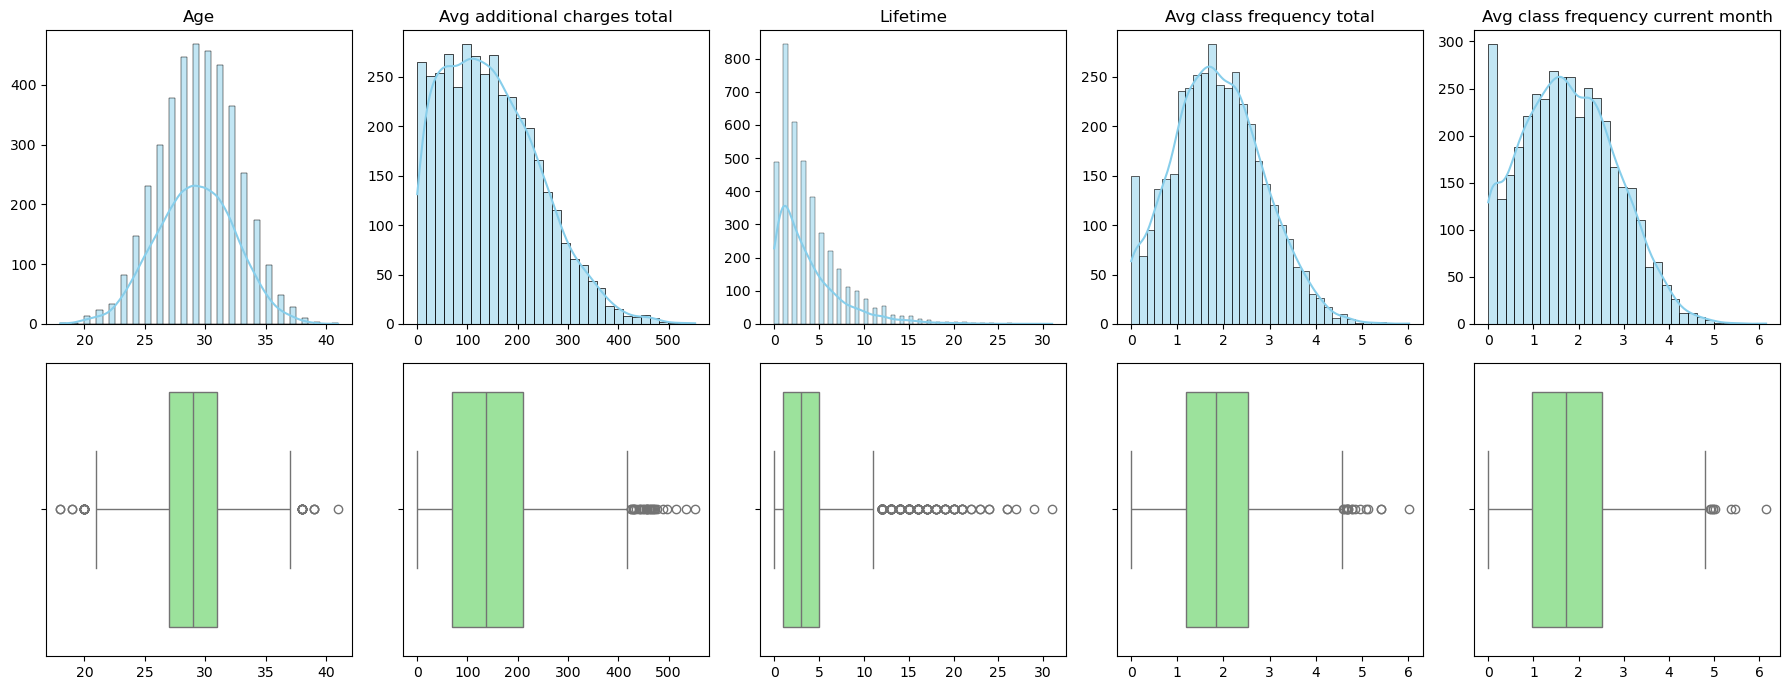

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

#Define the numerical variables:
nums = ['Age', 'Avg_additional_charges_total', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

fig, axes = plt.subplots(nrows=2, ncols=len(nums), figsize=(18, 7))

for i, col in enumerate(nums):
    sns.histplot(data=df, x=col, kde=True, ax=axes[0][i], color='skyblue')
    axes[0][i].set_title(col.replace('_', ' '))
    axes[0][i].set_ylabel("")
    axes[0][i].set_xlabel("")
    
    sns.boxplot(data=df, x=col, ax=axes[1][i], color='lightgreen')
    axes[1][i].set_ylabel("")
    axes[1][i].set_xlabel("")

plt.tight_layout()
plt.savefig('numerical_dist_analysis.png')

_Lifetime:

This is undoubtedly the strongest predictor. Retained customers have a much longer lifetime (the box is higher up). Churned customers have a very short lifetime, concentrated near zero. Most churn occurs among very new customers. If a customer stays for more than 3–4 months, the probability of them churning drops dramatically.

_Age:

Those who leave tend to be slightly younger. Younger customers may be more volatile or have short-term training goals.

_Avg_additional_charges_total (Additional Charges):

Those who stay (Churn = 0) have a higher average additional charge. More engaged customers tend to sign up for extra services (personal trainer, nutrition bar, special classes), which strengthens their connection to the gym.

_Avg_class_frequency_total (Total Frequency):

Retaining members come more often per week than those who leave. If visit frequency drops below a certain level, the user enters a “danger zone” for churn.

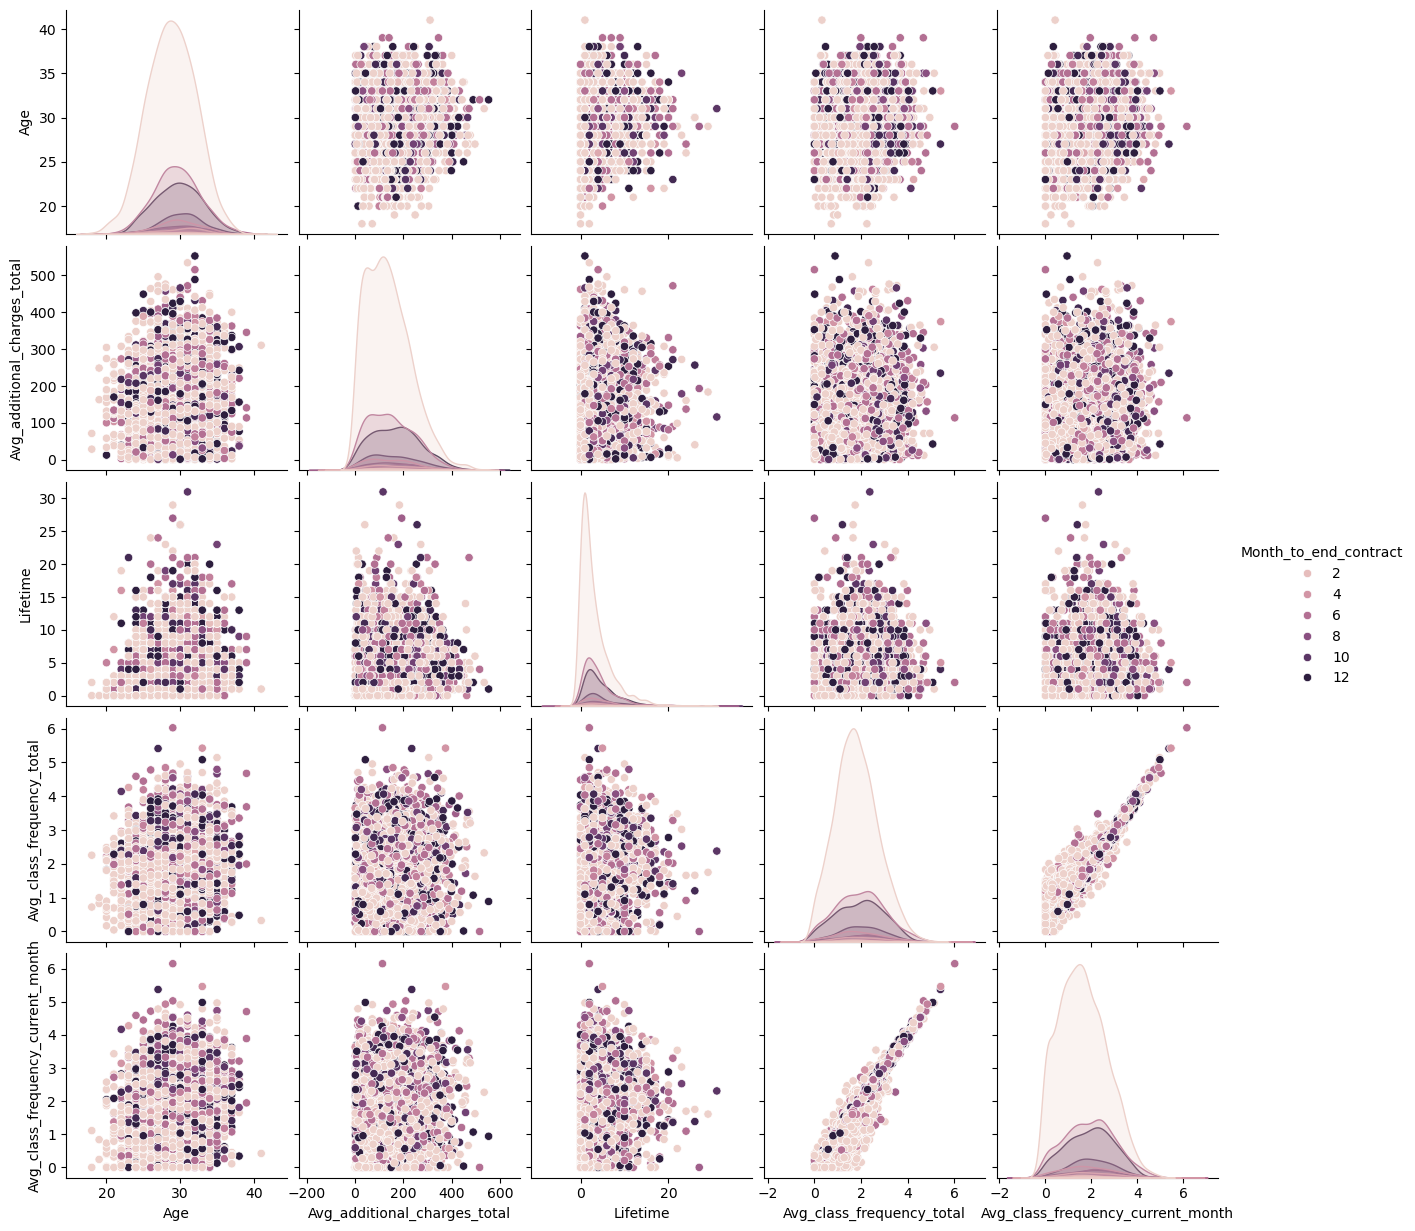

In [85]:
sns.pairplot(df, vars=nums, hue=cats[-1])
plt.show()

_ When comparing lifetime to any other variable, a clear distinction becomes apparent. The “orange” data points are almost always clustered at the lower end (near zero), which means that churn is predominantly a problem among new customers.

_ Customers who, during their first month (low Lifetime), take no more than 1 or 2 classes per week (low Frequency) are highly likely to leave



Average values and density plots for numerical features among following categorical features

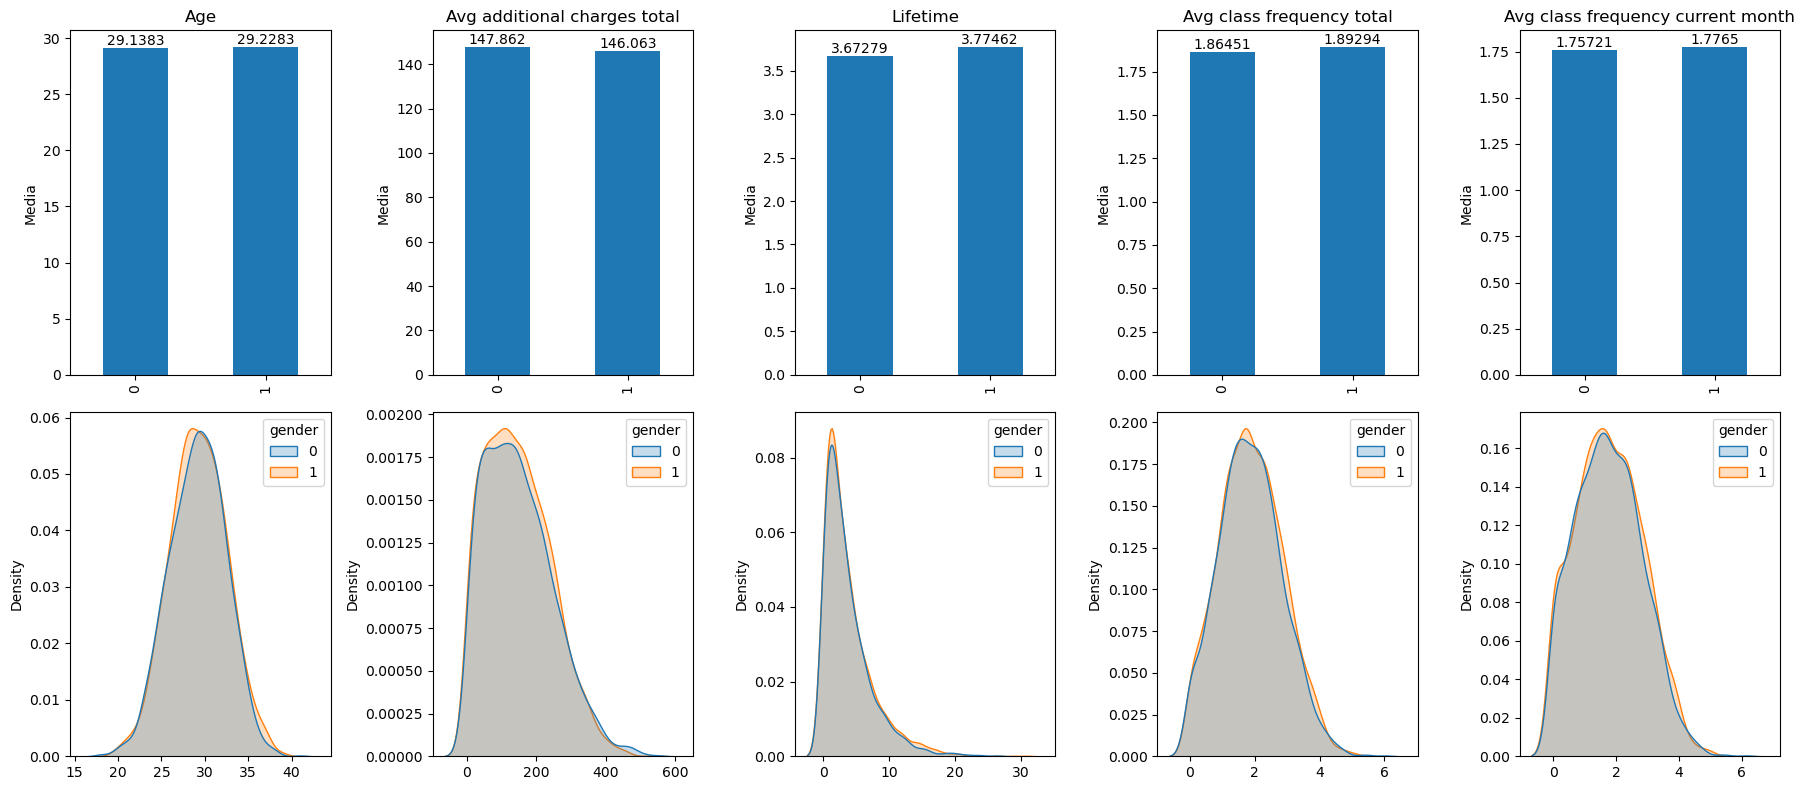

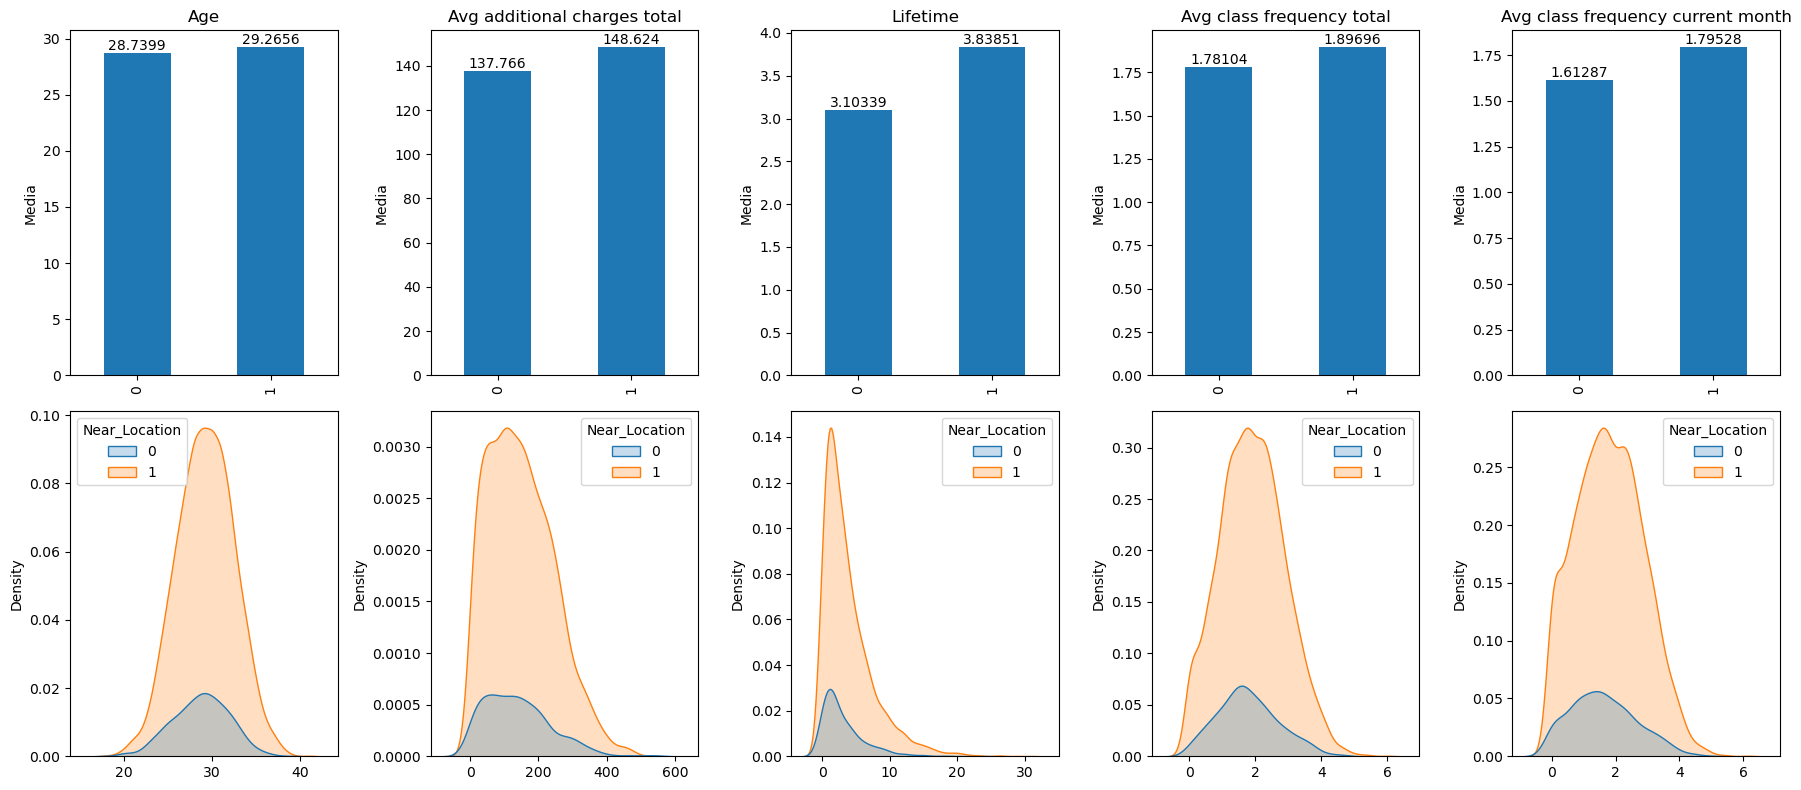

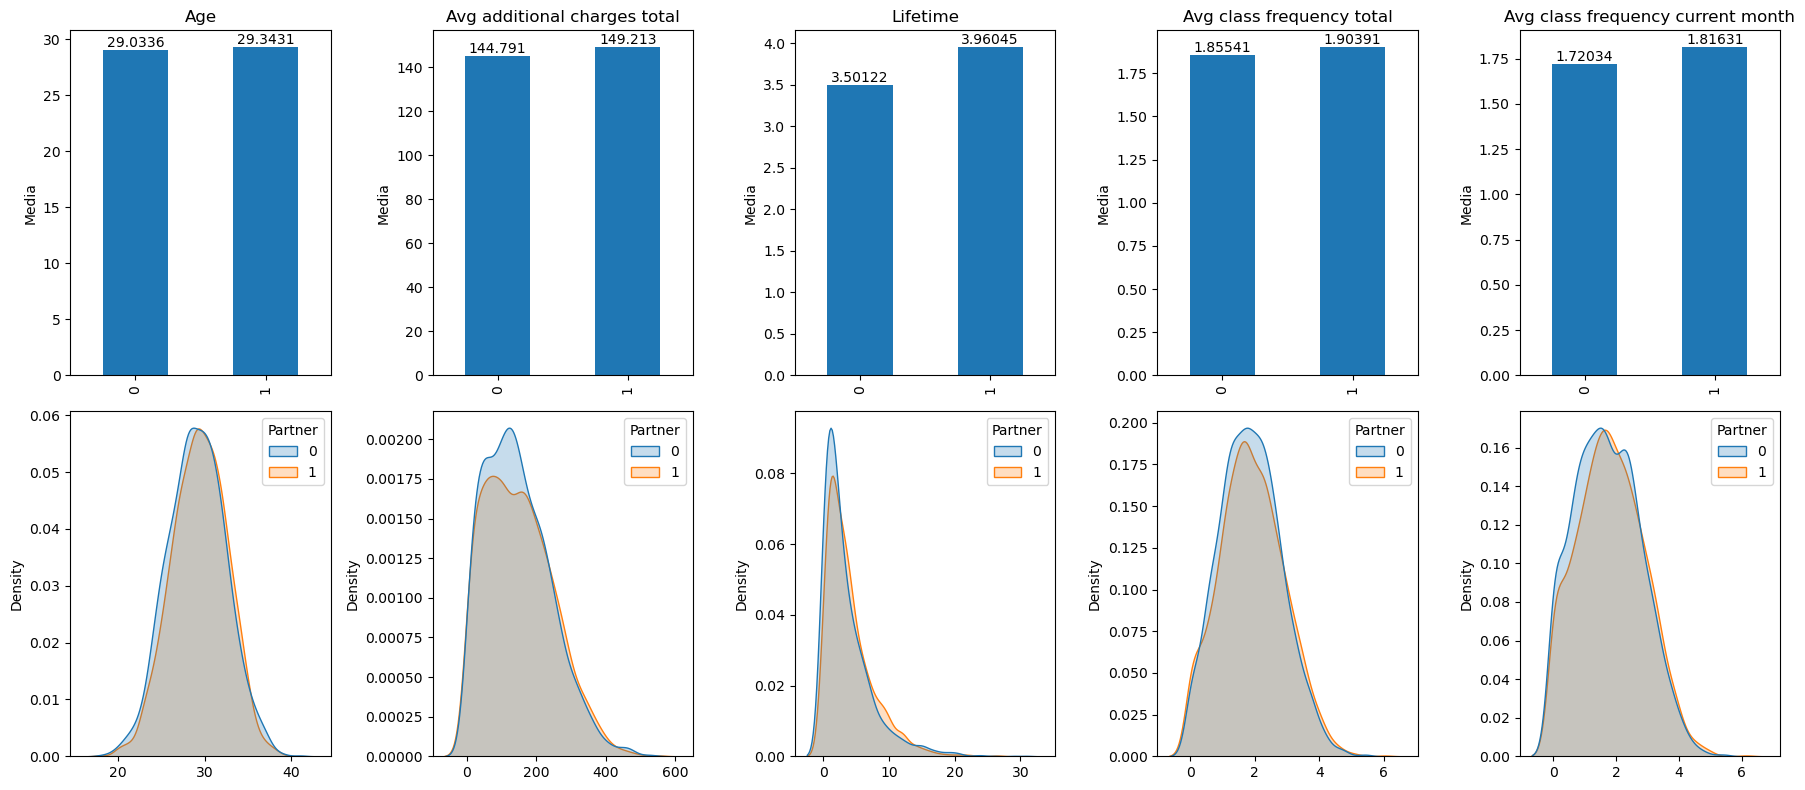

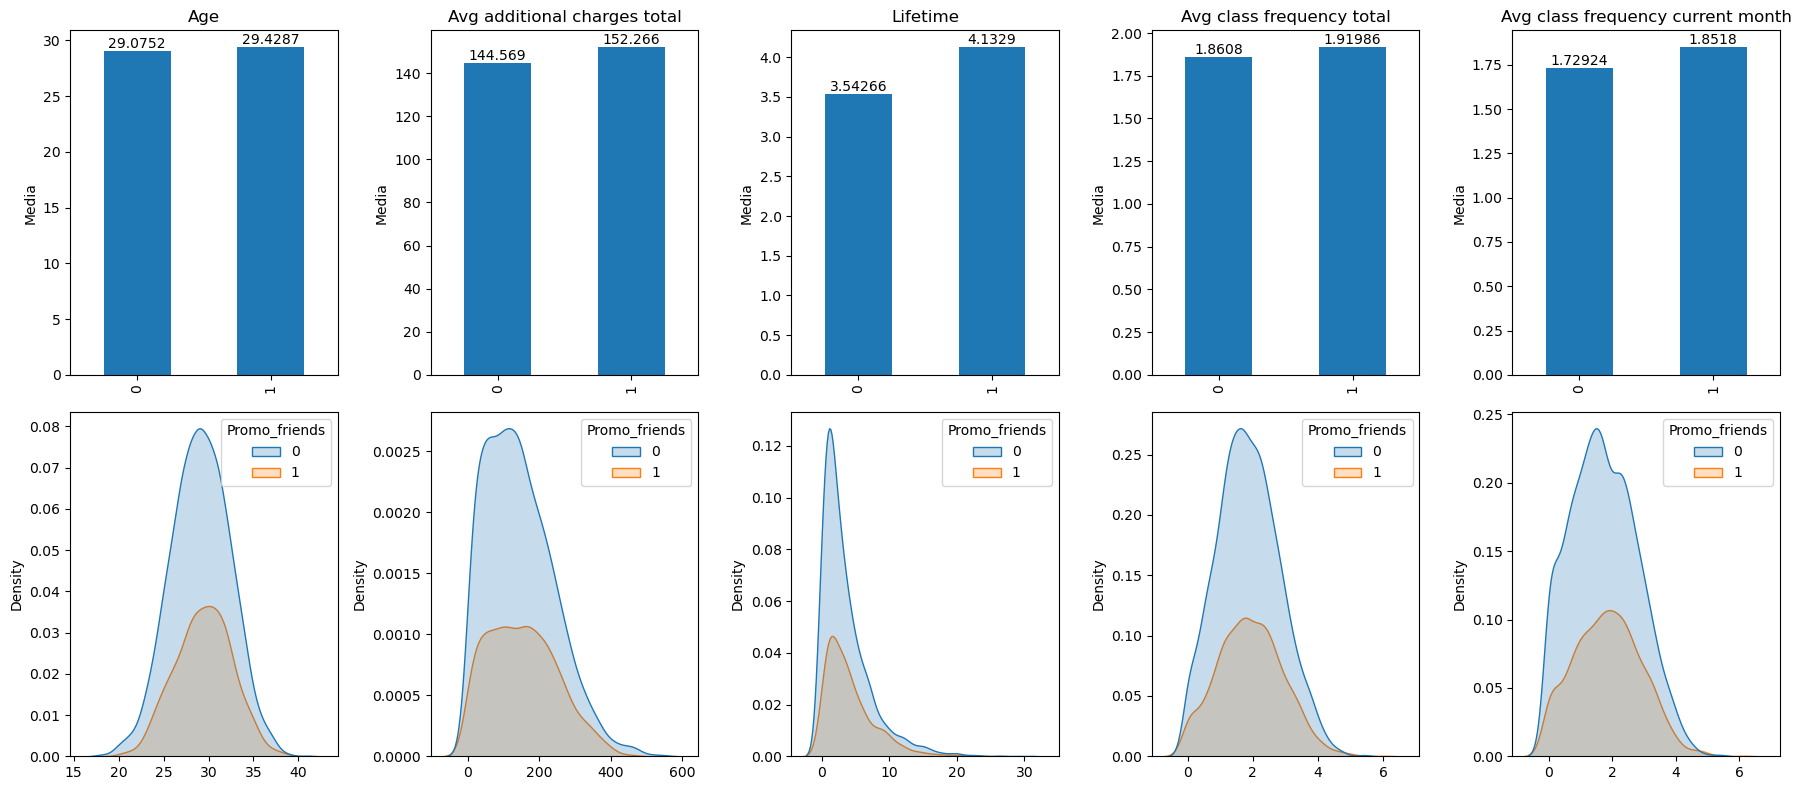

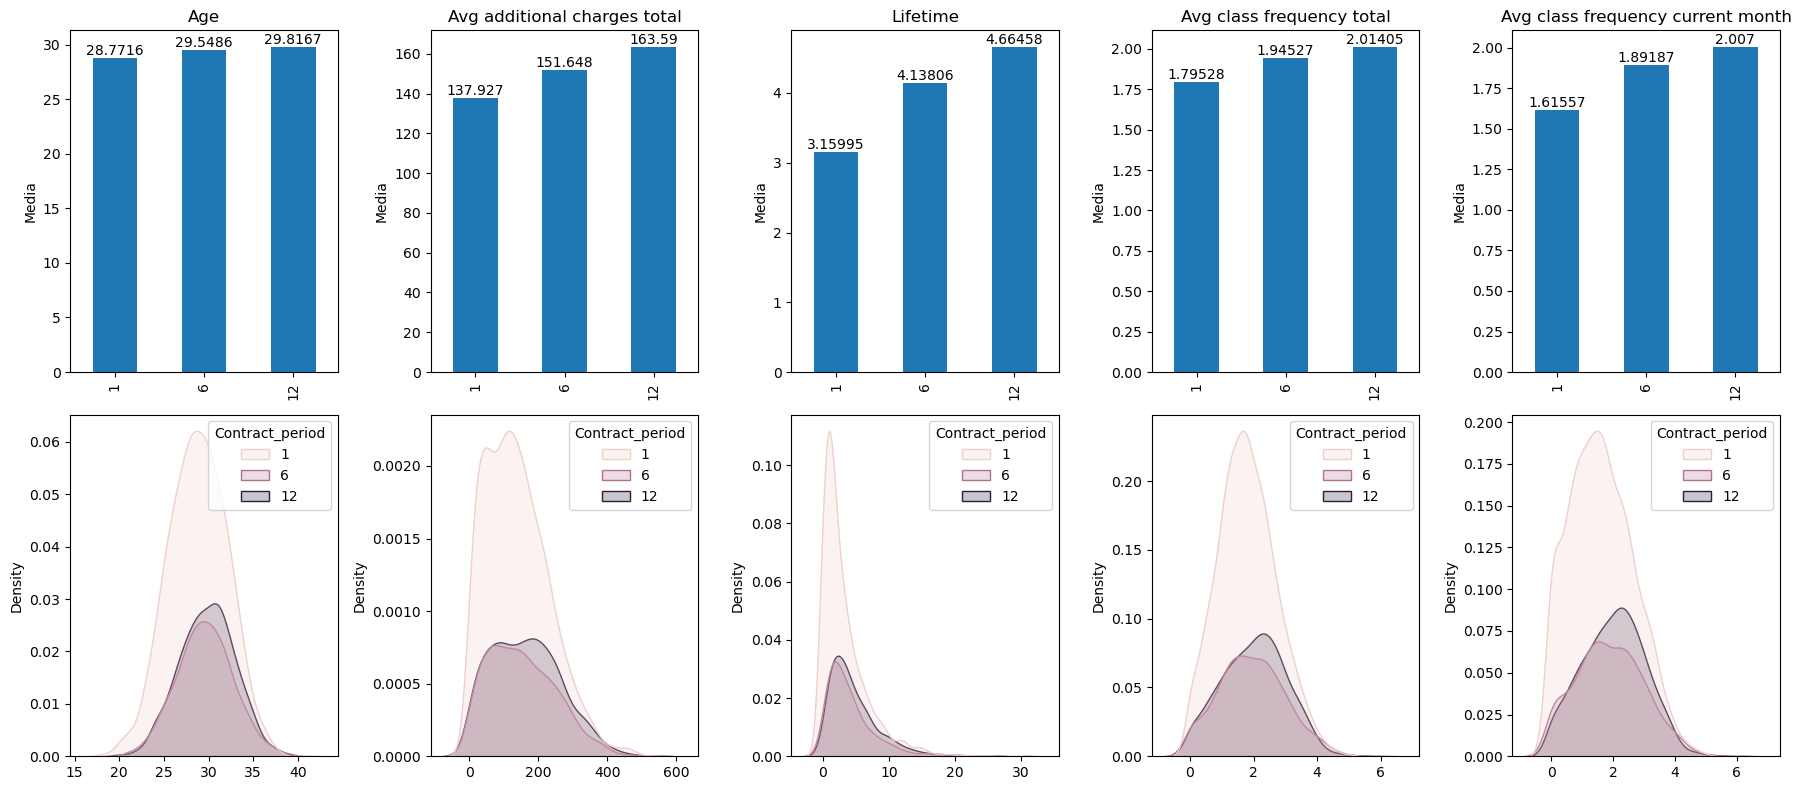

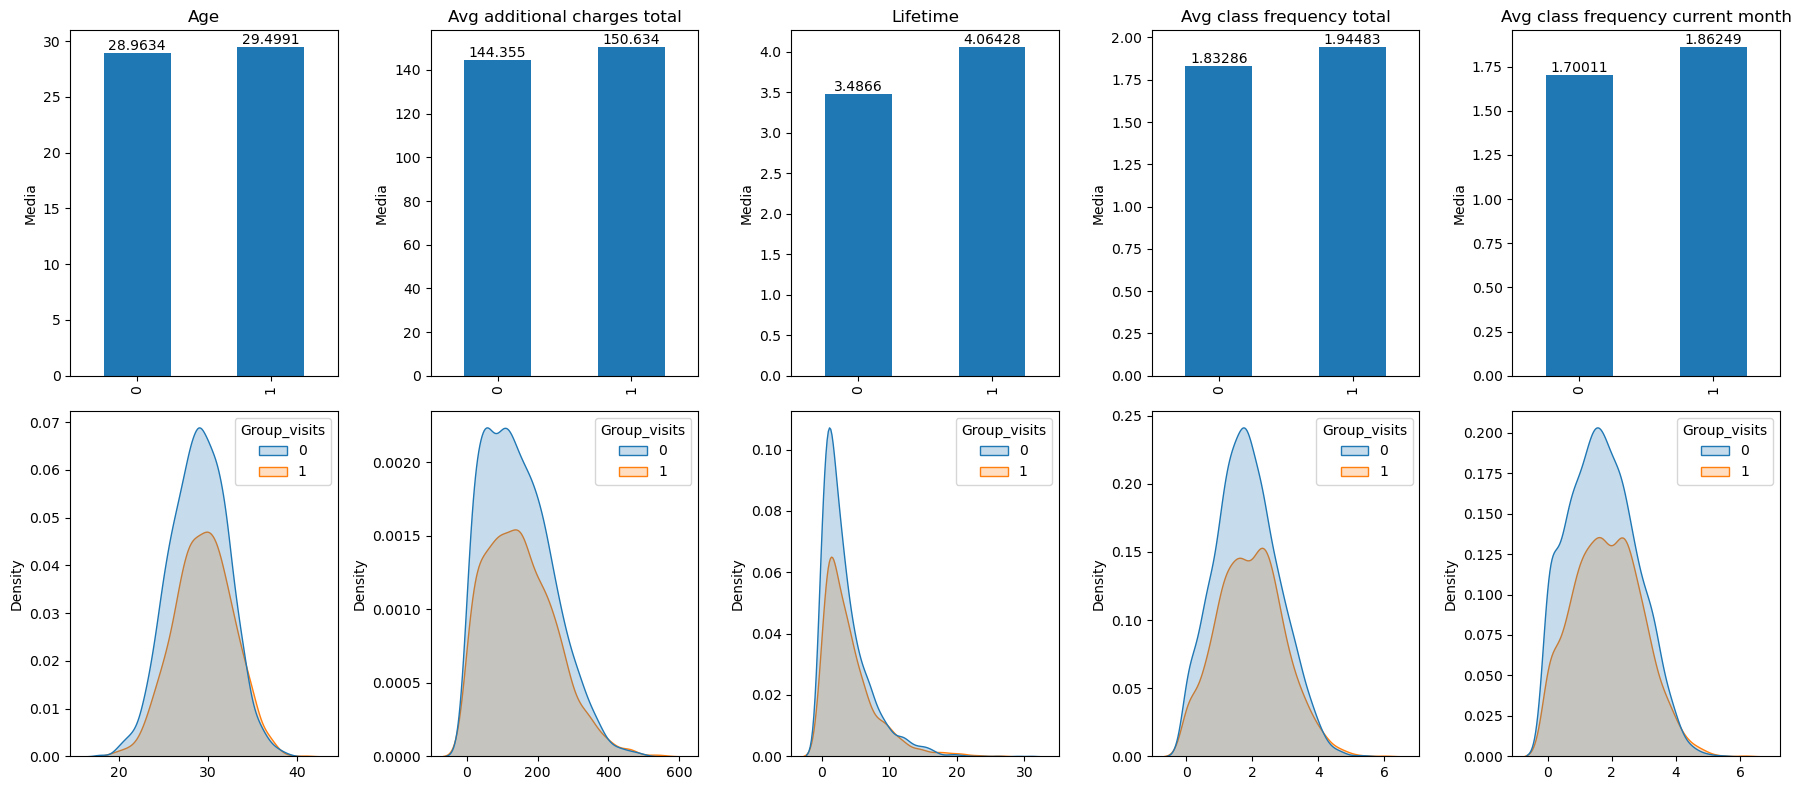

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML



for i in cats[:-1]: 
    display(HTML("<h2>Analysis for: {}</h2>".format(i.replace('_', ' '))))
    
    fig, axes = plt.subplots(nrows=2, ncols=len(nums), figsize=(18, 8))
    
    for j, k in enumerate(nums):
        grouped = df.groupby(i)[k].mean()
        if i == "Month_to_end_contract":
            grouped = grouped.sort_index()
            
        grouped.plot(kind="bar", ax=axes[0][j])
        for container in axes[0][j].containers:
            axes[0][j].bar_label(container, rotation=90 if i == "Month_to_end_contract" else 0)
            
        axes[0][j].set_title(k.replace('_', ' '))
        axes[0][j].set_ylabel("Media")
        axes[0][j].set_xlabel("")
        
        sns.kdeplot(data=df, x=k, hue=i, fill=True, ax=axes[1][j])
        axes[1][j].set_ylabel("Density")
        axes[1][j].set_xlabel("")

    plt.tight_layout()
    plt.savefig(f'analysis_{i}.png') #
    plt.show()

_Analysis by Contract_period (Contract):

In the bar chart above, customers with 12-month contracts have significantly higher averages for Lifetime and Avg_class_frequency_total.

Conclusion: There is a direct relationship between financial commitment (long-term contract) and usage commitment. The 1-month contract is your weak point (high risk of churn).

_ Analysis by Group_visits (Group Visits):

In the distribution charts (KDE, bottom section), the two curves (those who attend group classes vs. those who do not) are clearly separated.

Conclusion: Group classes are not just another activity; they are a retention mechanism, confirming that this is a variable that distinguishes loyal customers from temporary ones.

_Analysis by Partner (Corporate Partners):

Often, these customers come with corporate discounts, but that doesn’t stop them from spending on extra services if they are well integrated.

_Analysis by Near_Location:

The bar charts show that customers who live nearby (Near_Location=1) have a higher average Avg_class_frequency_total than those who live far away.

Conclusion: Proximity remains the most fundamental barrier. Customers who live far away need an “extra” boost of motivation to maintain their frequency. If a customer does not live nearby, they are a priority candidate for proactive retention strategies.

_ Analysis by Promo_friends
Observation: Here we see a clear difference in the distribution of Avg_additional_charges_total. Customers who joined through the friends promotion tend to spend more on additional services.

Conclusion: This validates the “Community Theory”: when someone joins with a friend, they not only stay longer (lower churn), but they also integrate more into the gym’s culture (additional spending).

BARCHAT

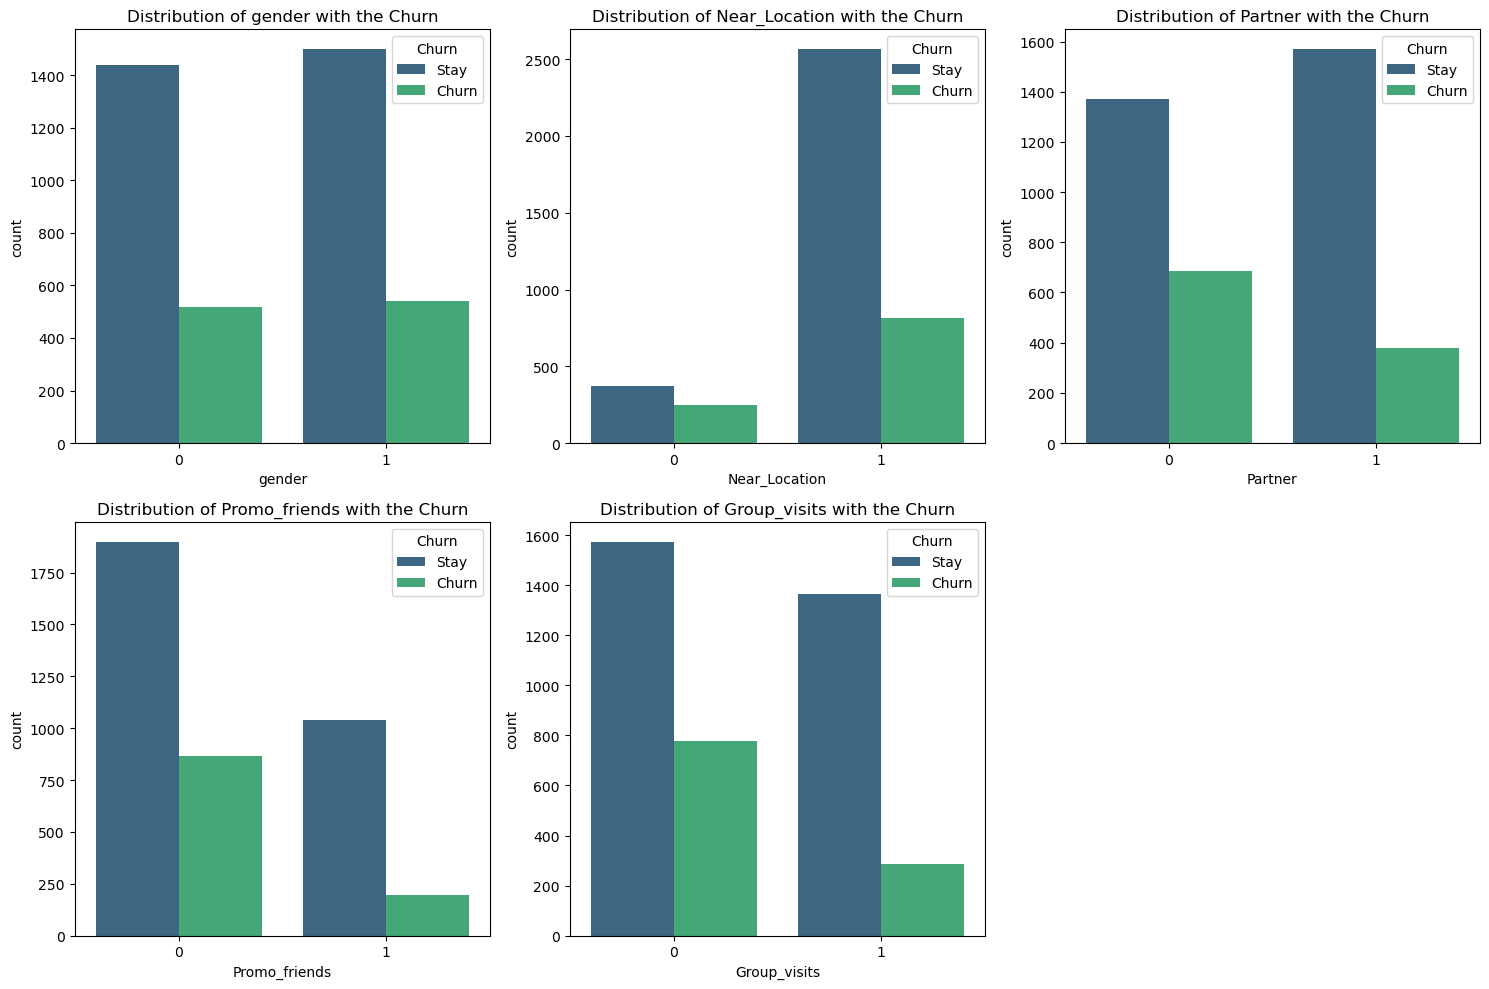

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_bar = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Group_visits']
plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_bar, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, hue='Churn', data=df, palette='viridis')
    plt.title(f'Distribution of {col} with the Churn')
    plt.legend(title='Churn', labels=['Stay', 'Churn'])

plt.tight_layout()
plt.show()

The variables with the strongest negative correlation with churn are customer tenure and visit frequency. This means that the longer a customer has been with us and the more often they visit, the less likely they are to leave.

Clients who participate in group classes have a much lower dropout rate compared to those who do not. This suggests that encouraging social interaction at the gym is an effective retention strategy

Customers who come through corporate partnerships (Partner) or referrals (Promo_friends) demonstrate greater loyalty, indicating that these acquisition channels are of high quality.

Gender does not appear to be a determining factor in churn, as the churn rate is similar in both groups

CORRELATION MATRIX

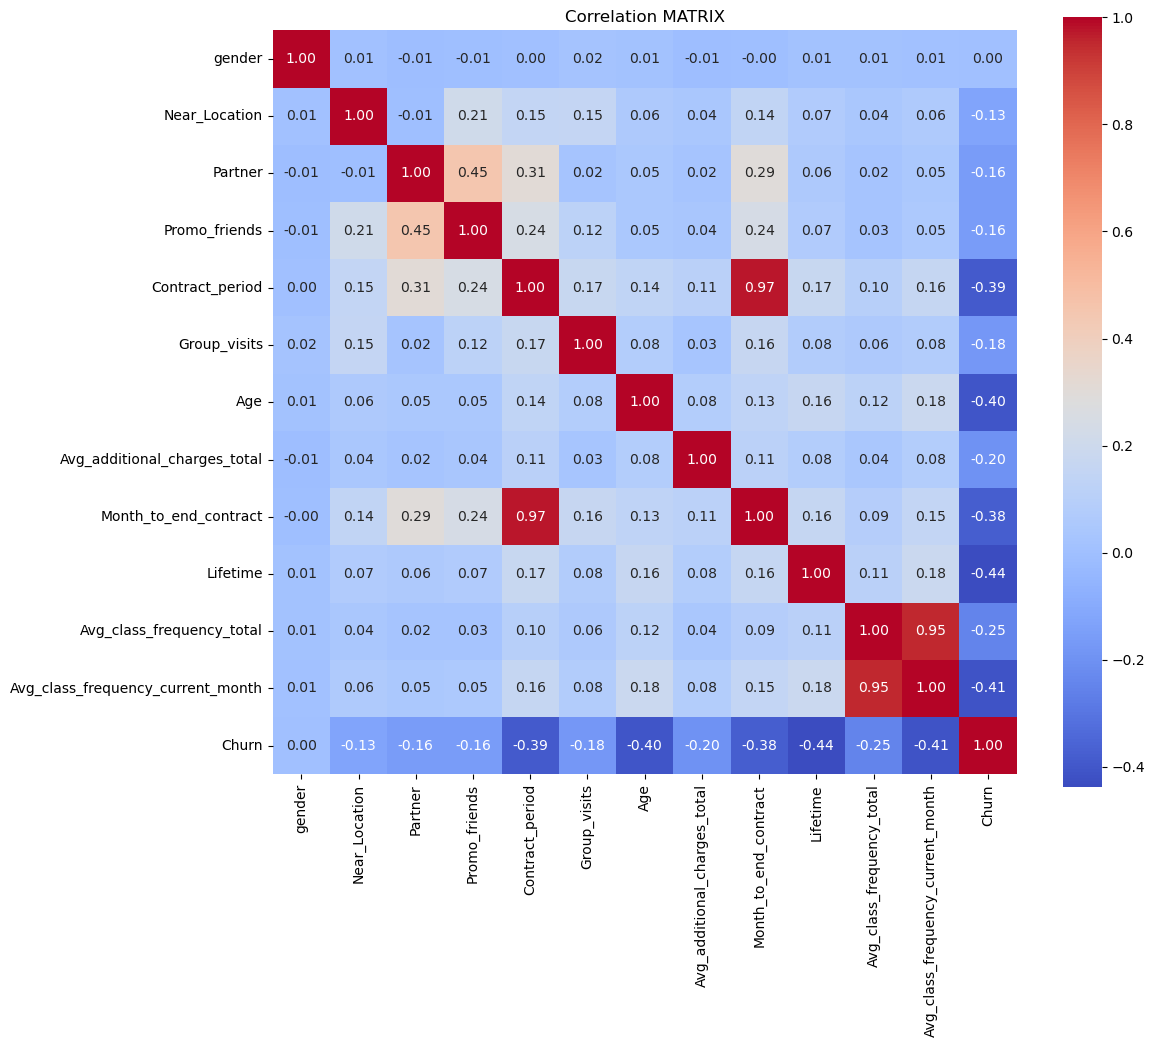

In [89]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, square=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation MATRIX')
plt.show()

A customer who has been with you for a long time (Lifetime), is older (Age), and has a long-term contract (Contract_period) is much less likely to leave.

It has detected a high degree of collinearity between contract duration and months remaining, as well as, average class frequency total and average frequency current month.

CORRELATION WITH CHURN

In [111]:
correlations = df.corr()['Churn'].sort_values(ascending=False)
print(correlations)

Churn                                1.000000
gender                               0.000708
cluster_km                          -0.107479
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64


. Lifetime (-0.44): The number one predictor. A customer who has been with the gym for a long time is very unlikely to leave. This is pure loyalty.

. Avg_class_frequency_current_month (-0.41): If the customer has attended classes frequently this past month, the risk of them leaving is very low. This is a sign of “active engagement.”

. Age (-0.40): Older members tend to be more stable and loyal than younger ones.

. Contract_period (-0.39) and Month_to_end_contract (-0.38): These confirm that long-term contracts are the backbone of retention.

. Avg_class_frequency_total (-0.25): Similar to the previous metric, but reflects long-term habits.

. Avg_additional_charges_total (-0.20): Customers who spend more on extras (nutrition, trainers, etc.) are more “loyal” to the gym.

. Group_visits (-0.18): The social factor acts as a barrier against churn.

. Promo_friends (-0.16) and Partner (-0.16): These customers get an extra boost thanks to their network of contacts or corporate benefits.

Churn according to the contract

In [112]:
contract = df.groupby('Contract_period')['Churn'].mean()
print(contract)

Contract_period
1     0.423199
6     0.124850
12    0.023958
Name: Churn, dtype: float64


The irrefutable proof: There’s a huge difference: 1-month contracts have a churn rate of 42%, while 12-month contracts barely reach 2%. This is your main conclusion for the professor: “The annual subscription model is the best defense against churn.” The impact ranking: Your correlation analysis confirms that Lifetime, Avg_class_frequency_current_month, and Age are the pillars that keep customers at the gym.


Delete the variables month to end contract and avg class frequency
We have already the varaibles Contract_period  and Avg_class_frequency_current_month  and the variables month to end contract and avg class frequency can confuse the model

In [121]:
df = df.drop(['Month_to_end_contract', 'Avg_class_frequency_total'], axis=1, errors='ignore')

Divide the customers into 5 groups

In [141]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
df_model = df.drop('Churn', axis=1, errors='ignore')
x_sc = scaler.fit_transform(df_model)

km = KMeans(n_clusters=5, random_state=0)
labels = km.fit_predict(x_sc)
df['cluster_km'] = labels

clusters_profile = df.groupby('cluster_km').mean()
print(clusters_profile)

              gender  Near_Location   Partner  Promo_friends  Contract_period  \
cluster_km                                                                      
0           0.509275       1.000000  0.165261       0.104553         2.357504   
1           0.481701       0.993076  0.960435       1.000000         7.125618   
2           0.566396       0.994580  0.463415       0.065041         8.155827   
3           0.503289       0.000000  0.486842       0.070724         2.952303   
4           0.502857       1.000000  0.228571       0.066667         2.199048   

            Group_visits        Age  Avg_additional_charges_total  Lifetime  \
cluster_km                                                                    
0               1.000000  28.806071                    128.010693  2.290051   
1               0.500495  29.485658                    151.356873  4.066271   
2               0.555556  30.731707                    183.290627  6.738482   
3               0.230263  28.682566  

_ Cluster 0: They attend group classes, have short-term contracts, and have little free time

_Cluster 1: They came because of friends, long-term contracts, and a strong commitment.

_Cluster 2: Long-term contracts and high-frequency trading lead to higher costs.

_Cluster 3: They live far away

_Cluster 4: No group classes, very low attendance, short-term contracts.

The segmentation analysis has allowed us to classify our customer base into five distinct profiles, with Cluster 0 standing out as the cornerstone of retention, boasting a minimal churn rate of 0.9% and characterized by high usage frequency and long-term commitment. Conversely, we have identified critical groups such as Cluster 2, which has the highest risk rate (40.2%) due primarily to a geographic barrier, and Cluster 3, whose low long-term engagement requires immediate attention upon the expiration of their short-term contracts. Finally, the success observed in Cluster 3, with a moderate churn rate of 13.4%, confirms that referral programs and participation in group activities act as powerful loyalty drivers, serving as a model to replicate for “Clients in Transition” (Cluster 1), who still present a significant churn risk of 35.5%

MACHINE LEARNING TO PREDICT

DIVIDE THE MODEL

In [148]:
X = df.drop('Churn', axis=1, errors='ignore')
y = df['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

KKN model

--- Report (KNN) ---
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       588
           1       0.71      0.86      0.78       212

    accuracy                           0.87       800
   macro avg       0.83      0.87      0.84       800
weighted avg       0.88      0.87      0.87       800

   
   
   


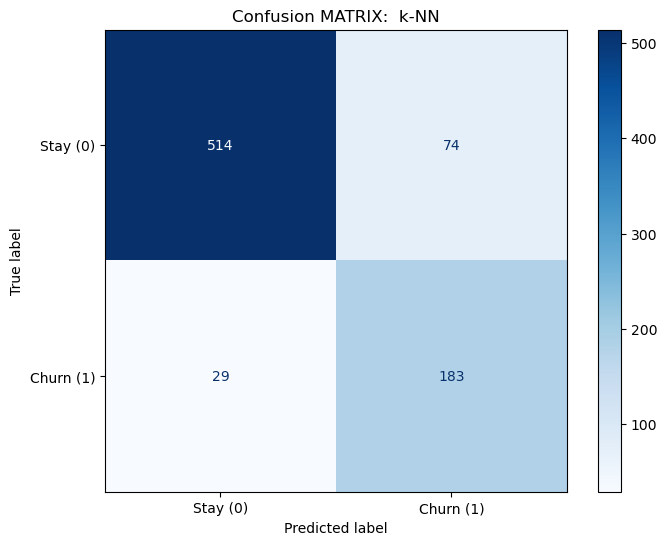

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_knn = knn_model.predict(X_test_scaled)

print("--- Report (KNN) ---")
print(classification_report(y_test, y_pred_knn))
print ("   ")
print ("   ")
print ("   ")


cm = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])

disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion MATRIX:  k-NN')
plt.show()

Logistic Regression

--- Report ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       588
           1       0.85      0.83      0.84       212

    accuracy                           0.92       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.92      0.92      0.92       800



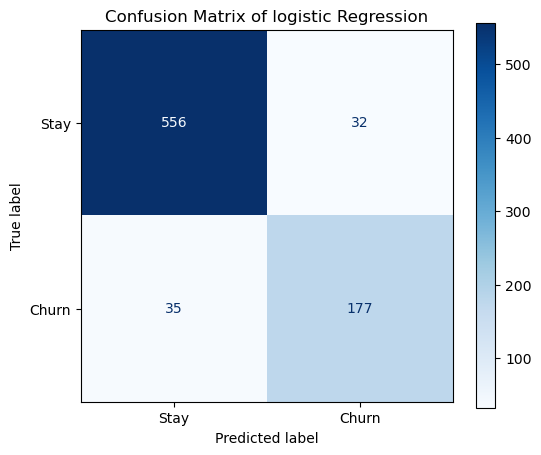

In [150]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

log_model = LogisticRegression(random_state=0)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# Report
print("--- Report ---")
print(classification_report(y_test, y_pred_log))

# Confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix of logistic Regression')
plt.show()


In [151]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(solver='liblinear')
log_model.fit(X_train_scaled, y_train)

coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_model.coef_[0]
})

coefficients["abs_coef"] = coefficients["coefficient"].abs()
coefficients = coefficients.sort_values("abs_coef", ascending=False)

print(coefficients)

                              feature  coefficient  abs_coef
8                            Lifetime    -3.541611  3.541611
4                     Contract_period    -1.374270  1.374270
9   Avg_class_frequency_current_month    -1.275311  1.275311
6                                 Age    -1.151161  1.151161
7        Avg_additional_charges_total    -0.561916  0.561916
5                        Group_visits    -0.345711  0.345711
3                       Promo_friends    -0.143297  0.143297
1                       Near_Location    -0.060898  0.060898
2                             Partner    -0.052263  0.052263
10                         cluster_km     0.032077  0.032077
0                              gender     0.023843  0.023843


_The Key Factor: Lifetime (-3.54)

This is by far the most important factor. Such a high negative value means that the longer a customer has been with the gym, the significantly lower their likelihood of leaving. This confirms that your strategy should focus on getting past the first few months.

_Commitment: Contract_period (-1.37)

This confirms that members with long-term contracts are much more loyal. This validates the importance of promoting annual or semi-annual memberships.

_Activity: Avg_class_frequency_current_month (-1.27)

Attendance frequency is a critical indicator of customer health. If a customer stops coming, the model detects it immediately.

_Age: Age (-1.15)

It appears that your slightly older customers tend to be more stable than very young ones.

DESICION CLASSIFIER

--- Report ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       588
           1       0.80      0.78      0.79       212

    accuracy                           0.89       800
   macro avg       0.86      0.85      0.86       800
weighted avg       0.89      0.89      0.89       800



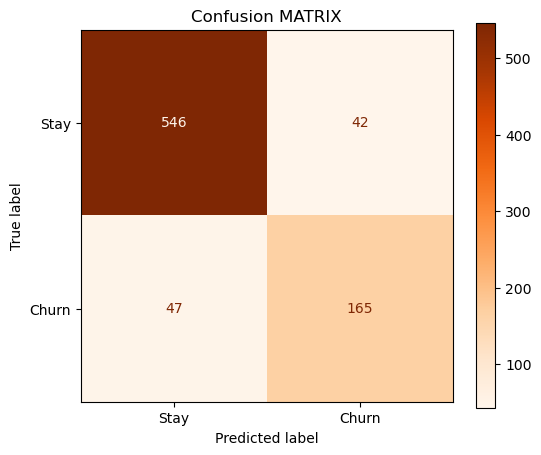

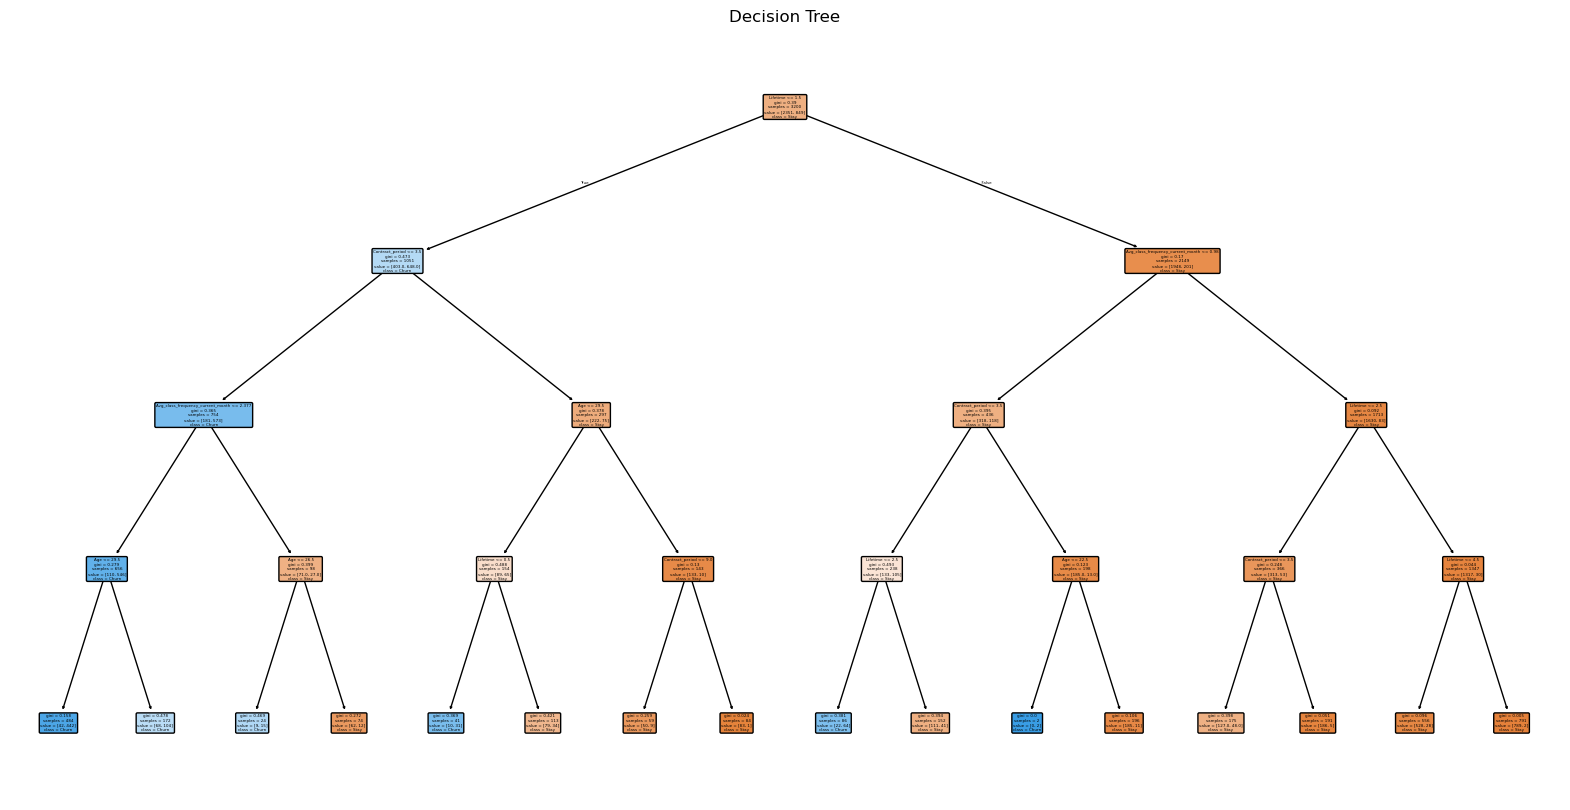

In [134]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

# Report
print("--- Report ---")
print(classification_report(y_test, y_pred_tree))

#Confusion MATRIX
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Oranges', ax=plt.gca())
plt.title('Confusion MATRIX')
plt.show()

# Display the three
plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=X.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True)
plt.title('Decision Tree')
plt.show()

Gradient boost

--- Report ---
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       588
           1       0.86      0.81      0.84       212

    accuracy                           0.92       800
   macro avg       0.90      0.88      0.89       800
weighted avg       0.92      0.92      0.92       800



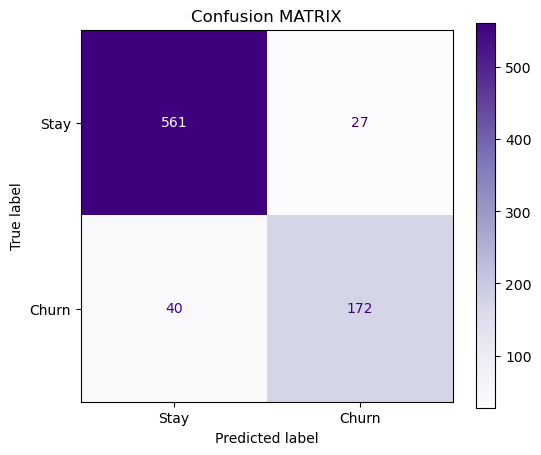

In [135]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Report
print("--- Report ---")
print(classification_report(y_test, y_pred_gb))

# Confusion MATRIX
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Purples', ax=plt.gca())
plt.title('Confusion MATRIX')
plt.show()

COMPARE THE 4 MODELS

In [139]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = [] 

for name, model, data in final_model:
    y_pred = model.predict(data)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

table_results = pd.DataFrame(results)
print(table_results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression   0.91625   0.843602 0.839623  0.841608
               k-NN   0.88750   0.796117 0.773585  0.784689
      Decision Tree   0.88875   0.797101 0.778302  0.787589
  Gradient Boosting   0.91625   0.864322 0.811321  0.836983


When we are comparing the models, we observe that logistic regression offers the most robust balance (F1 score: 0.84). In a business context such as a gym, this means that our model is capable of detecting most at-risk customers (high Recall) while minimizing false positives among loyal customers (high Precision), which is critical for optimizing the marketing department’s budget.

Hyperparameter Tuning

In [155]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}


grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='recall')

grid_search.fit(X_train_scaled, y_train)

best_log = grid_search.best_estimator_

y_pred_best = best_log.predict(X_test_scaled)

print(f"Best parameter: {grid_search.best_params_}")
print(f"--- Report ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_best):.4f}")

Best parameter: {'C': 0.001, 'solver': 'liblinear'}
--- Report ---
Accuracy: 0.8850
Recall:   0.8538


After performing hyperparameter tuning using GridSearchCV, we optimized the regularization parameter C to 0.001 using the liblinear solver. This configuration increased the model’s recall to 85.38%, reinforcing our customer churn prevention strategy by prioritizing the identification of positive cases over the model’s overall accuracy.

In [159]:
!pip install openpyxl